In [1]:
import numpy as np

In [2]:
X = np.array([[1,-1],
              [-np.sqrt(3),np.sqrt(3)],
              [2,-2]])

In [3]:
X

array([[ 1.        , -1.        ],
       [-1.73205081,  1.73205081],
       [ 2.        , -2.        ]])

In [12]:
_,_,V_t = np.linalg.svd(X)

In [13]:
V = V_t.T

In [16]:
proj_X_V = X @ V

In [17]:
proj_X_V

array([[-1.41421356e+00,  1.11022302e-16],
       [ 2.44948974e+00, -1.21193281e-16],
       [-2.82842712e+00,  2.22044605e-16]])

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris

In [33]:
from numpy.linalg import inv
from scipy.stats import zscore
from numpy.linalg import qr
from numpy.linalg import cholesky as chol
from numpy.linalg import eig
from numpy.linalg import svd

In [34]:
iris = load_iris()

In [35]:
X = iris.data
y = iris.target

In [36]:
feature_names = ['Sepal length, x1', 'Sepal width, x2',
                 'Petal length, x3', 'Petal width, x4']

X_df = pd.DataFrame(X,columns = feature_names)

X = X_df.to_numpy()

Text(0.5, 1.0, 'X')

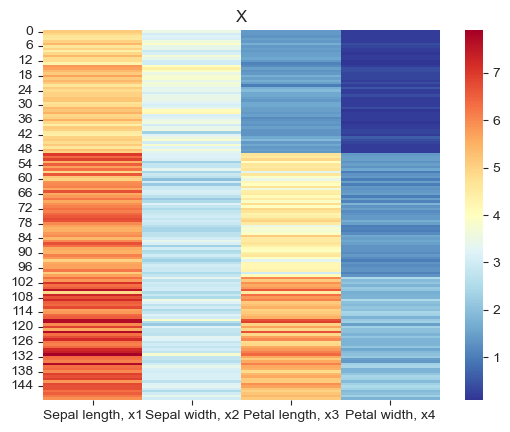

In [55]:
sns.set_style('ticks') #简洁显示风格
fig,ax = plt.subplots()
ax = sns.heatmap(X,
                 cmap = 'RdYlBu_r',
                 xticklabels = list(X_df.columns),
                 cbar_kws = {'orientation' : 'vertical'})
plt.title('X')

In [56]:
G = X.T @ X

Text(0.5, 1.0, 'G')

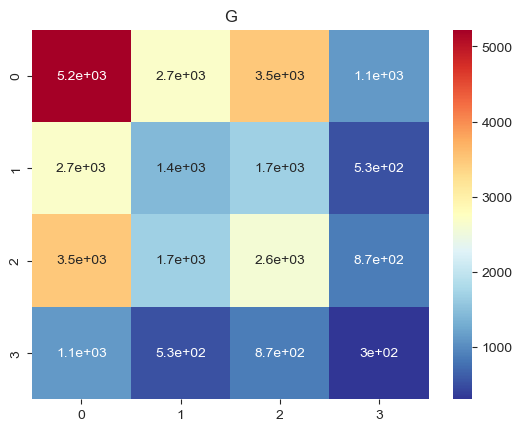

In [58]:
fig,ax = plt.subplots()
ax = sns.heatmap(G,
                 cmap = 'RdYlBu_r',
                 cbar_kws = {'orientation' : 'vertical'},
                 annot = True)
plt.title('G')

In [59]:
S_norm = np.diag(np.sqrt(np.diag(G)))

In [60]:
C = inv(S_norm) @ G @ inv(S_norm)

Text(0.5, 1.0, 'C')

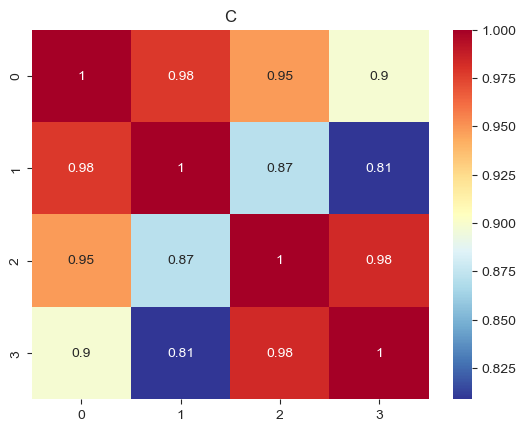

In [61]:
fig,ax = plt.subplots()
ax = sns.heatmap(C,
                 cmap = 'RdYlBu_r',
                 cbar_kws = {'orientation' : 'vertical'},
                 annot = True)
plt.title('C')

In [66]:
E_X = X_df.mean().to_frame().T #mean出来的是Series(1d),to_frame转为df数组(2d),.T转置
E_X

,"Sepal length, x1","Sepal width, x2","Petal length, x3","Petal width, x4"
0,5.843333,3.057333,3.758,1.199333


In [68]:
X_c = X_df.sub(X_df.mean())

Text(0.5, 1.0, 'X_c')

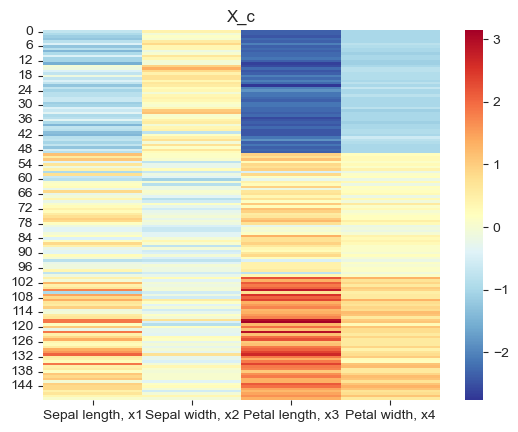

In [69]:
sns.set_style('ticks') #简洁显示风格
fig,ax = plt.subplots()
ax = sns.heatmap(X_c,
                 cmap = 'RdYlBu_r',
                 xticklabels = list(X_df.columns),
                 cbar_kws = {'orientation' : 'vertical'})
plt.title('X_c')

In [70]:
SIGMA = X_df.cov()

Text(0.5, 1.0, 'SIGMA')

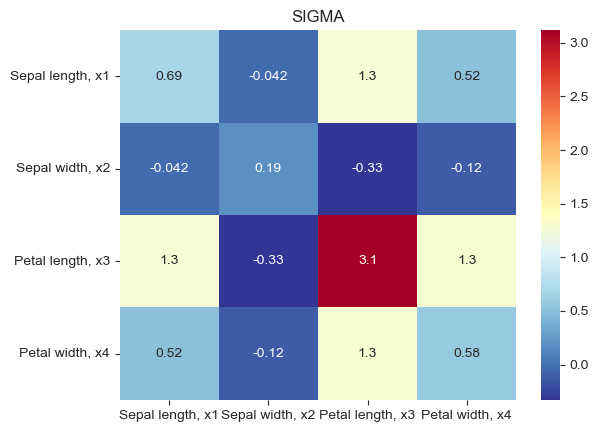

In [72]:
fig,ax = plt.subplots()
ax = sns.heatmap(SIGMA,
                 cmap = 'RdYlBu_r',
                 cbar_kws = {'orientation' : 'vertical'},
                 annot = True)
plt.title('SIGMA')

In [73]:
RHO = X_df.corr()

Text(0.5, 1.0, 'RHO')

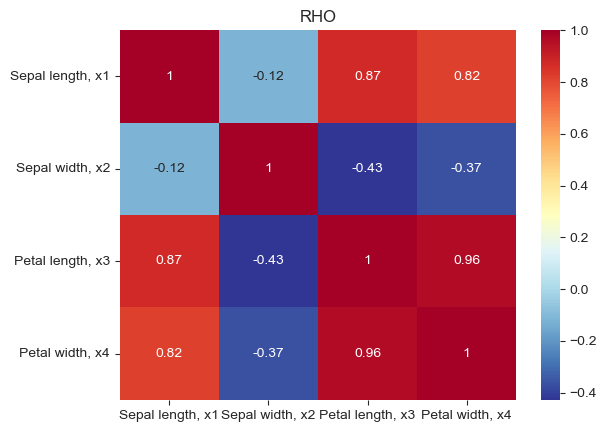

In [74]:
fig,ax = plt.subplots()
ax = sns.heatmap(RHO,
                 cmap = 'RdYlBu_r',
                 cbar_kws = {'orientation' : 'vertical'},
                 annot = True)
plt.title('RHO')

In [75]:
Z_X = zscore(X_df)

Text(0.5, 1.0, 'Z_X')

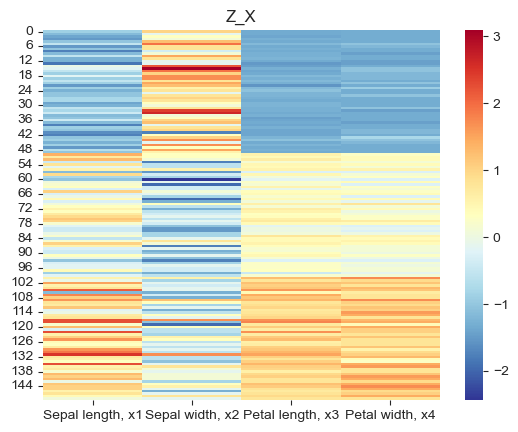

In [77]:
sns.set_style('ticks') #简洁显示风格
fig,ax = plt.subplots()
ax = sns.heatmap(Z_X,
                 cmap = 'RdYlBu_r',
                 xticklabels = list(X_df.columns),
                 cbar_kws = {'orientation' : 'vertical'})
plt.title('Z_X')

In [79]:
Q,R = qr(X_df,mode = 'reduced') #reduced保留最小矩阵维度

Text(0.5, 1.0, 'R')

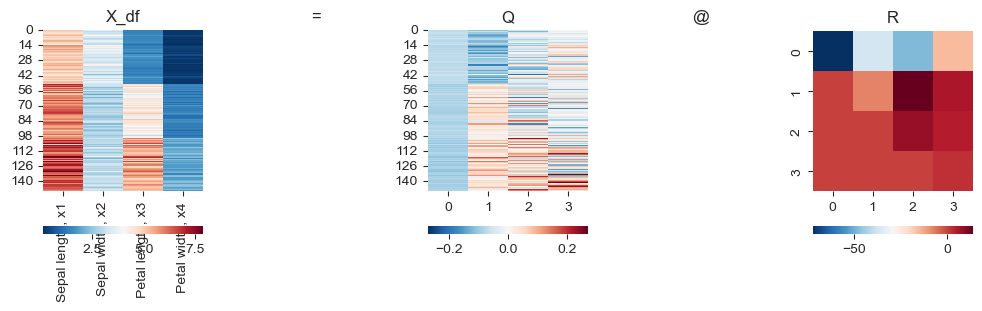

In [84]:
fig,axs = plt.subplots(1,5,figsize = (12,3))

plt.sca(axs[0])
ax = sns.heatmap(X_df,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
plt.title('X_df')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(Q,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
plt.title('Q')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(R,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('R')

In [86]:
L_G = chol(G) #得到下三角矩阵
R_G = L_G.T

Text(0.5, 1.0, 'R_G')

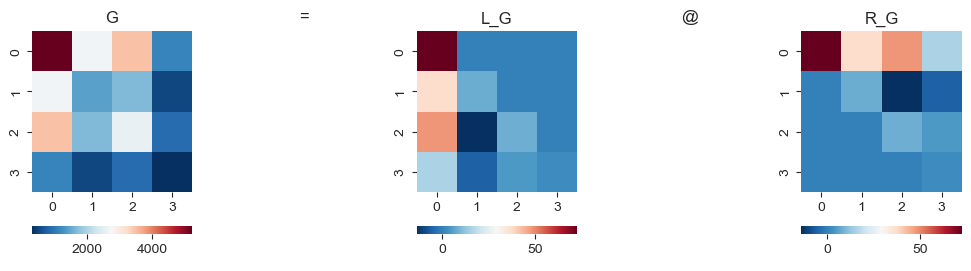

In [87]:
fig,axs = plt.subplots(1,5,figsize = (12,3))

plt.sca(axs[0])
ax = sns.heatmap(G,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('G')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(L_G,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('L_G')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(R_G,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('R_G')

In [88]:
L_Sigma = chol(SIGMA)
R_Sigma = L_Sigma.T

Text(0.5, 1.0, 'R_Sigma')

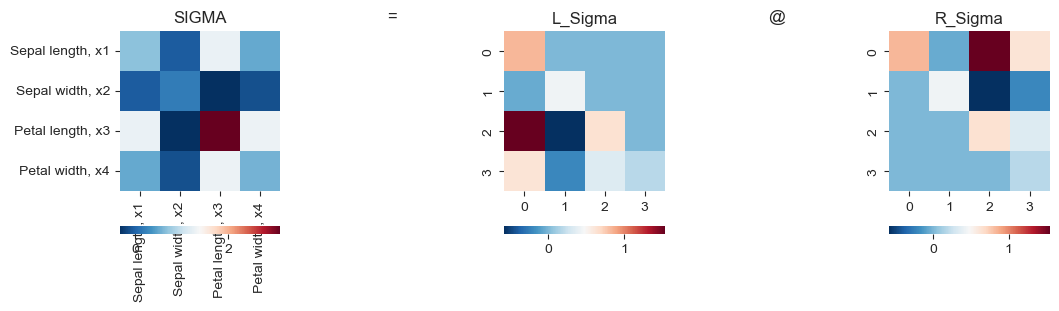

In [89]:
fig,axs = plt.subplots(1,5,figsize = (12,3))

plt.sca(axs[0])
ax = sns.heatmap(SIGMA,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('SIGMA')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(L_Sigma,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('L_Sigma')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(R_Sigma,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('R_Sigma')

In [91]:
Lambs_G ,V_G = eig(G)
Lambs_G = np.diag(Lambs_G)

Text(0.5, 1.0, 'V_G.T')

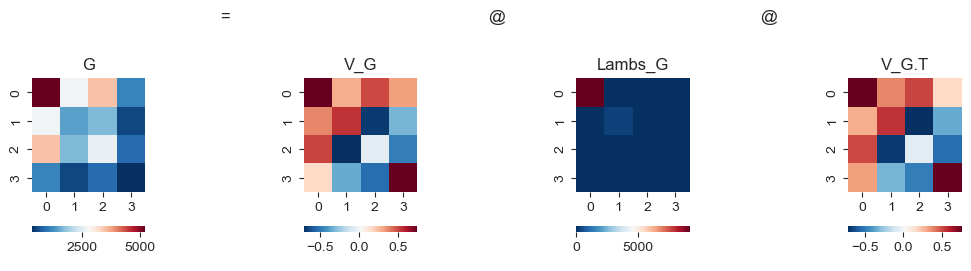

In [96]:
fig,axs = plt.subplots(1,7,figsize = (12,3))

plt.sca(axs[0])
ax = sns.heatmap(G,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('G')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(V_G,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('V_G')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(Lambs_G,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('Lambs_G')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V_G.T,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('V_G.T')

In [99]:
Lambs_sigma,V_sigma = eig(SIGMA)
Lambs_sigma = np.diag(Lambs_sigma)

Text(0.5, 1.0, 'V_sigma.T')

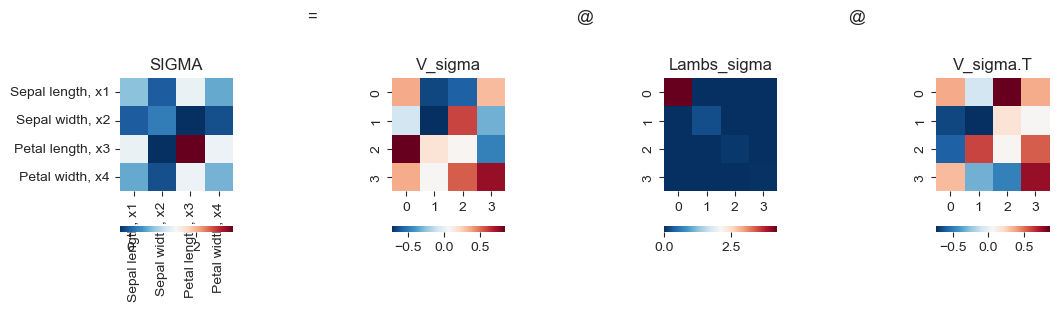

In [100]:
fig,axs = plt.subplots(1,7,figsize = (12,3))

plt.sca(axs[0])
ax = sns.heatmap(SIGMA,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('SIGMA')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(V_sigma,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('V_sigma')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(Lambs_sigma,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('Lambs_sigma')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V_sigma.T,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('V_sigma.T')

In [101]:
Lambs_P,V_P = eig(RHO)
Lambs_P = np.diag(Lambs_P)

Text(0.5, 1.0, 'V_P.T')

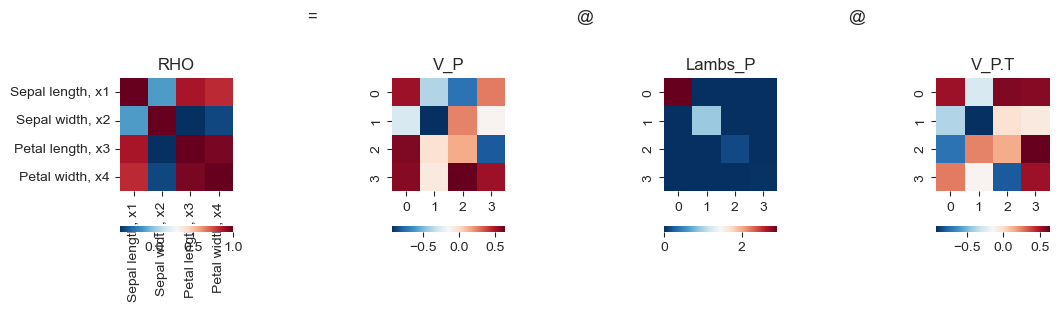

In [102]:
fig,axs = plt.subplots(1,7,figsize = (12,3))

plt.sca(axs[0])
ax = sns.heatmap(RHO,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('RHO')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(V_P,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('V_P')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(Lambs_P,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('Lambs_P')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V_P.T,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('V_P.T')

In [105]:
U_X,S_X,V_X = svd(X_df,full_matrices = False)
V_X = V_X.T
S_X = np.diag(S_X)

Text(0.5, 1.0, 'V_X')

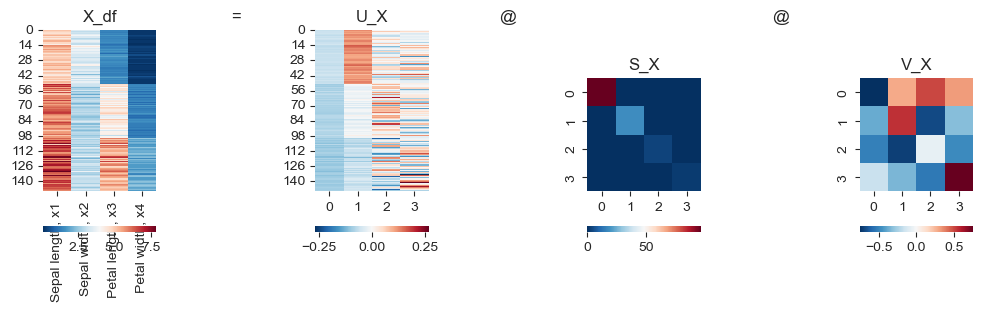

In [106]:
fig,axs = plt.subplots(1,7,figsize = (12,3))

plt.sca(axs[0])
ax = sns.heatmap(X_df,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
plt.title('X_df')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(U_X,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
plt.title('U_X')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(S_X,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('S_X')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V_X,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('V_X')

In [107]:
U_Xc,S_Xc,V_Xc = svd(X_c,full_matrices = False)
V_Xc = V_Xc.T
S_Xc = np.diag(S_Xc)

Text(0.5, 1.0, 'V_Xc')

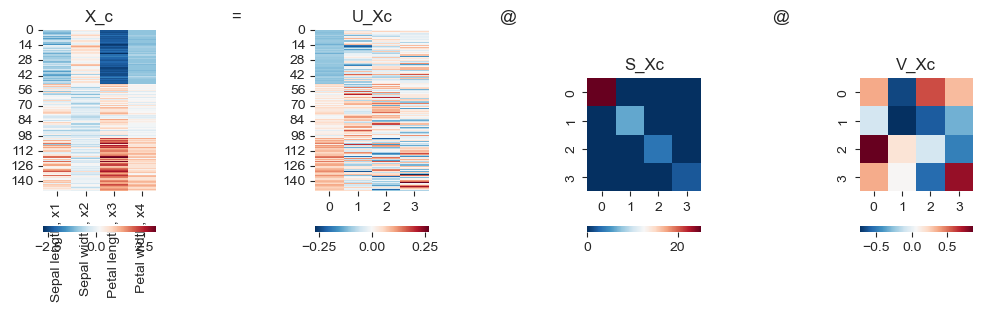

In [108]:
fig,axs = plt.subplots(1,7,figsize = (12,3))

plt.sca(axs[0])
ax = sns.heatmap(X_c,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
plt.title('X_c')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(U_Xc,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
plt.title('U_Xc')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(S_Xc,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('S_Xc')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V_Xc,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('V_Xc')

In [109]:
U_Z,S_Z,V_Z = svd(Z_X,full_matrices = False)
V_Z = V_Z.T
S_Z = np.diag(S_Z)

Text(0.5, 1.0, 'V_Z')

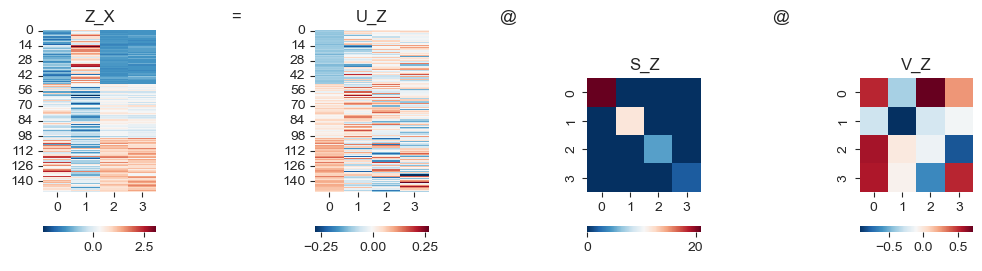

In [110]:
fig,axs = plt.subplots(1,7,figsize = (12,3))

plt.sca(axs[0])
ax = sns.heatmap(Z_X,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
plt.title('Z_X')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(U_Z,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
plt.title('U_Z')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(S_Z,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('S_Z')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V_Z,cmap = 'RdBu_r',
                 cbar_kws = {'orientation' : 'horizontal'})
ax.set_aspect('equal')
plt.title('V_Z')